# Klassifikation der Eigenwerte mit LazyClassifier (Train/Test + CV)

**Setup.** Features = Eigenwerte pro Run, Label = Fault-Klasse `0..20` (Integer,
**kein** One-Hot — lazypredict/sklearn erwarten 1D-Klassenlabels).

**Datenfluss.**
- **Train-Eigenwerte:** werden aus den CSVs gelesen, die
  `PCA_eigenwerte.ipynb` / `DyCA_Eigenwerte.ipynb` (Trainings-Analyse) schreiben.
- **Test-Eigenwerte:** werden **hier** aus den TEP-Test-CSVs berechnet — mit
  derselben per-Run-Funktion wie im Training, nur mit Cutoff **161** (Test:
  Fehler nach 8 h, 960 Samples/Run). Ergebnis wird als
  `*_eigenvalues_test.csv` gecached, damit Re-Runs nicht neu rechnen müssen.

  Zwei Punkte, die man dabei kennen sollte:
  - Der `scaler` wird gefittet, übergeben und von beiden Funktionen
    **angewandt** (`X_scaled = scaler.transform(X)`) — identisch zu den
    Analyse-Notebooks nach deren Umstellung.
  - Die **Fensterlängen sind angeglichen**: die Test-Runs werden auf die
    Train-Fensterlänge gekürzt (Fault 0: 500 Samples, Fault 1–20: 480
    Post-Fault-Samples = 24 h nach Fehlereintritt) — im Code markiert als
    `TODO(Fenster-Angleich)`. Ohne die Kürzung stammten die Test-Eigenwerte
    aus 800/960-Sample-Fenstern, die Train-Eigenwerte aber aus 480/500.

So bleiben `PCA_eigenwerte.ipynb` / `DyCA_Eigenwerte.ipynb` reine
Trainings-Analyse; der Testdatensatz wird nur hier angefasst.

**Skalierung.** Aktuell aktiv: `scaler.transform(X)` (spaltenweise
Standardisierung in Normalbetriebs-Einheiten). Wie in den Analyse-Notebooks
ist die einzige umzuschaltende Stelle die Zeile `X_scaled = ...`
(`X - X.mean()` ↔ `scaler.transform(X)`). Beim Umschalten alle
`*_eigenvalues_*.csv` neu erzeugen — die alten `global_mean`-Ergebnisse
liegen als `*_global_mean.csv` archiviert.

**Bewertung.** `LazyClassifier(cv=5)`: 5-fache CV auf **Train** (Spalten
`… CV Mean/Std`) ist die Basis der **Modellauswahl**; die Spalten ohne `CV` sind
die **einmalige** Bewertung auf dem echten Testset. Drei Durchläufe: PCA, DyCA,
PCA+DyCA.

> Laufzeit/Speicher: die Test-Berechnung lädt `TEP_Faulty_Testing.csv` (3,4 GB)
> und rechnet PCA+DyCA über ~10000 Runs — **einmalig**, danach gecached. Plus
> ~30 Klassifizierer × 5 Folds × 3 Sätze (Server/über Nacht, ggf. tmux).

## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep). Dieses Notebook
enthält nur noch die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/spectra.py` | Registry der Verfahren, hier für die **Test**-Spektren gebraucht |
| `tep/eigen/classify.py` | Feature-Sätze, Modellvergleich, Confusion-Matrizen |

Die **Train**-Spektren kommen aus den Eigenwert-Notebooks (`*_eigenvalues_train*.csv`),
die **Test**-Spektren rechnet dieses Notebook selbst und legt sie als
`*_eigenvalues_test*.csv` ab — beim zweiten Lauf werden sie von dort
gelesen.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen; alle sechs Spektrum-Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen.


In [1]:
# ============================================================
# Imports - der gemeinsame Unterbau steckt im Paket tep
# ============================================================
# %load_ext autoreload
# %autoreload 2
import numpy as np
import pandas as pd

from tep.eigen import SpectrumConfig, versions
from tep.eigen.classify import (ClassifyConfig, class_distribution,
                                confusion, counts, feature_sets,
                                plot_confusions, report_confusions,
                                run_lazyclassifier, test_spectra,
                                train_spectra)

print(versions())

tsfresh 0.21.2 | pandas 3.0.3 | numpy 2.4.6 | sklearn 1.9.0 | Kerne: 8


In [2]:
# ============================================================
# Konfiguration - die EINZIGE Stelle, an der geschraubt wird
# ============================================================
# Je Verfahren eine SpectrumConfig: sie bestimmt, WELCHE CSV geladen
# bzw. berechnet wird und mit welchen Parametern. Die DyCA-Werte muessen
# zu denen passen, mit denen DyCA_Eigenwerte.ipynb die Train-CSV
# erzeugt hat - sonst waeren Train- und Test-Spektren verschieden
# parametriert.
CFGS = [
    SpectrumConfig(method="pca", scaling_mode="scaler"),
    SpectrumConfig(method="dyca", scaling_mode="scaler",
                   dyca_m=2, dyca_n=4),
]

# Modellvergleich: 5-fache CV auf den TRAININGSdaten, Auswahl ueber
# "Balanced Accuracy CV Mean" - also ohne Blick aufs Testset.
CC = ClassifyConfig(cv_folds=5,
                    select_metric="Balanced Accuracy CV Mean",
                    random_state=42)

## Spektren beschaffen

Die **Train**-Spektren erzeugen die Eigenwert-Notebooks (`PCA_eigenwerte.ipynb`, `DyCA_Eigenwerte.ipynb`) — sie müssen einmal gelaufen sein. Die **Test**-Spektren rechnet dieses Notebook und legt sie als CSV ab, damit ein zweiter Lauf die großen Test-CSVs nicht erneut anfassen muss.

Die Selektion hat ausschließlich Trainingsdaten gesehen — das Testset bleibt eine unverzerrte Generalisierungsschätzung.

In [3]:
# ============================================================
# Spektren laden: Train aus den Eigenwert-Notebooks, Test hier
# ============================================================
# Die Test-CSVs sind gross (3,4 GB fuer Faulty_Testing) - sie werden nur
# gelesen, wenn mindestens ein Verfahren wirklich rechnen muss. Beim
# zweiten Lauf kommt alles aus dem CSV-Cache.
#
# Wichtig ist die Fensterangleichung: im Training deckt ein Lauf 500
# (Fault 0) bzw. 480 (Fault != 0) Samples ab, im Test 960 bzw. 800.
# SpectrumConfig.as_test() kuerzt entsprechend, sonst waeren Train- und
# Test-Spektren systematisch verschieden.
train = train_spectra(CFGS)
test = test_spectra(CFGS)

# Ein Feature-Satz je Verfahren plus die Kombination (INNER JOIN auf
# fault/run - nur Laeufe, die alle Verfahren ueberlebt haben).
SETS = feature_sets(CFGS, train, test, combine=True)
for s in SETS:
    print(f"{s.name:12s} {s.n_features:3d} Features | "
          f"train {s.train.shape} test {s.test.shape}")

PCA-Train geladen: (10500, 54)
DyCA-Train geladen: (10443, 54)
PCA-Test aus Cache: (10500, 54) (.\pca_eigenvalues_test_scaler.csv)
DyCA-Test aus Cache: (10435, 54) (.\dyca_eigenvalues_test_scaler.csv)
PCA           52 Features | train (10500, 54) test (10500, 54)
DyCA          52 Features | train (10443, 54) test (10435, 54)
PCA+DyCA     104 Features | train (10443, 106) test (10435, 106)


## Klassenverteilung prüfen

Bevor Modelle verglichen werden: sind die Klassen in Train und Test überhaupt gleich stark besetzt? DyCA verliert einzelne Läufe an numerischem Scheitern — fällt der Verlust auf wenige Fehlerklassen, ist der Vergleich mit PCA nicht mehr ganz fair.

In [4]:
# ============================================================
# Klassenverteilung in Train und Test
# ============================================================
# Die Verlust-Spalten zeigen, wo ein Verfahren Laeufe einbuesst (DyCA
# scheitert an einzelnen numerisch). Klassen mit hohem Verlust sind
# Kandidaten fuer einen Selektions-Bias.
dist = class_distribution(SETS)

print(dist.to_string())

             PCA_train  PCA_test  DyCA_train  DyCA_test  PCA+DyCA_train  PCA+DyCA_test  verlust_DyCA_train  verlust_PCA+DyCA_train  verlust_DyCA_test  verlust_PCA+DyCA_test
faultNumber                                                                                                                                                                 
0                  500       500         499        497             499            497                   1                       1                  3                      3
1                  500       500         496        499             496            499                   4                       4                  1                      1
2                  500       500         498        498             498            498                   2                       2                  2                      2
3                  500       500         498        496             498            496                   2                       2     

## Modellvergleich

`LazyClassifier` fittet rund 25 Klassifizierer je Feature-Satz. Ausgewählt wird über die **Train-CV** (`Balanced Accuracy CV Mean`), nicht über das Testergebnis — sonst wäre die Modellwahl selbst schon eine Anpassung an das Testset (Winner's Curse).

Balanced Accuracy ist der Macro-Recall und sieht Precision nicht; lazypredicts eigene `F1 Score`-Spalte ist die *gewichtete* Variante. Beide Zahlen sind mit Vorsicht zu lesen, die Confusion-Matrizen darunter sagen mehr.

In [5]:
# ============================================================
# Modellvergleich je Feature-Satz
# ============================================================
# Sortiert nach der Train-CV, nicht nach dem Testergebnis. Modelle ohne
# predict_proba bekommen keine CV-Werte (der ROC-AUC-Scorer scheitert und
# leert alle CV-Spalten) und landen am Tabellenende.
leaderboards = {s.name: run_lazyclassifier(s, CC) for s in SETS}

leaderboards[SETS[-1].name]

=== PCA ===
Features: 52 | Train: 10500 | Test: 10500 | Klassen: 21 | cv=5
Hinweis: 8 Modelle ohne CV-Werte am Tabellenende (ROC-AUC-Scorer scheitert ohne predict_proba). Staerkste nach Test-BA: SVC 0.8737, LinearSVC 0.8730, NuSVC 0.8450
Leaderboard sortiert nach 'Balanced Accuracy CV Mean' (nur im Speicher, keine CSV).
=== DyCA ===
Features: 52 | Train: 10443 | Test: 10435 | Klassen: 21 | cv=5
Hinweis: 10 Modelle ohne CV-Werte am Tabellenende (ROC-AUC-Scorer scheitert ohne predict_proba). Staerkste nach Test-BA: SVC 0.7943, NuSVC 0.7674, LinearSVC 0.7492
Leaderboard sortiert nach 'Balanced Accuracy CV Mean' (nur im Speicher, keine CSV).
=== PCA+DyCA ===
Features: 104 | Train: 10443 | Test: 10435 | Klassen: 21 | cv=5
Hinweis: 10 Modelle ohne CV-Werte am Tabellenende (ROC-AUC-Scorer scheitert ohne predict_proba). Staerkste nach Test-BA: LinearSVC 0.9182, SVC 0.9057, NuSVC 0.8893
Leaderboard sortiert nach 'Balanced Accuracy CV Mean' (nur im Speicher, keine CSV).


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Accuracy CV Mean,Accuracy CV Std,Balanced Accuracy CV Mean,Balanced Accuracy CV Std,ROC AUC CV Mean,ROC AUC CV Std,F1 Score CV Mean,F1 Score CV Std,Precision CV Mean,Precision CV Std,Recall CV Mean,Recall CV Std,Time Taken
Model,,,,,,,,,,,,,,,,,,,
LogisticRegression,0.918448,0.918378,0.995345,0.917422,0.917641,0.918448,0.916212,0.002166,0.916284,0.002100,0.995017,0.000334,0.914950,0.002703,0.914688,0.002674,0.916212,0.002166,5.758283
CalibratedClassifierCV,0.919789,0.919717,0.994616,0.918315,0.918211,0.919789,0.913722,0.001863,0.913804,0.001711,0.994320,0.000266,0.911703,0.002241,0.911461,0.002082,0.913722,0.001863,20.482416
RandomForestClassifier,0.906756,0.906680,0.994075,0.904052,0.903622,0.906756,0.905105,0.004035,0.905180,0.004019,0.993793,0.000497,0.900944,0.004595,0.899747,0.005105,0.905105,0.004035,23.795866
ExtraTreesClassifier,0.905319,0.905232,0.993869,0.900974,0.901180,0.905319,0.903764,0.001993,0.903832,0.002102,0.993583,0.000199,0.898308,0.002946,0.896834,0.002565,0.903764,0.001993,4.156129
LinearDiscriminantAnalysis,0.901869,0.901818,0.994344,0.901344,0.901512,0.901869,0.900220,0.003118,0.900293,0.003168,0.993968,0.000232,0.898947,0.003097,0.899067,0.003558,0.900220,0.003118,4.034944
BaggingClassifier,0.893436,0.893373,0.988326,0.893000,0.893566,0.893436,0.895146,0.005219,0.895209,0.005056,0.987187,0.001772,0.893819,0.004526,0.894051,0.004497,0.895146,0.005219,19.233132
DecisionTreeClassifier,0.873407,0.873369,0.933540,0.874202,0.875170,0.873407,0.871781,0.005059,0.871877,0.005023,0.932682,0.002657,0.871523,0.005151,0.871734,0.005517,0.871781,0.005059,3.087468
GaussianNB,0.862482,0.862429,0.989412,0.855646,0.858464,0.862482,0.868909,0.007913,0.868957,0.008006,0.990375,0.001116,0.864127,0.009291,0.865455,0.010156,0.868909,0.007913,0.977227
KNeighborsClassifier,0.848874,0.848800,0.972805,0.848462,0.853006,0.848874,0.846309,0.005895,0.846312,0.006021,0.971451,0.002467,0.845976,0.006194,0.850651,0.006394,0.846309,0.005895,1.675891


## Confusion-Matrizen

Ein **fester** Modelltyp (RandomForest) auf jedem Feature-Satz, auf dem gesamten Trainingssatz gefittet und **einmal** auf dem echten Testset ausgewertet. Die Unterschiede zwischen den Matrizen liegen damit allein an den Features, nicht an der Modellwahl.

In [6]:
# ============================================================
# Confusion-Matrizen: RandomForest auf jedem Feature-Satz
# ============================================================
# Fester Modelltyp ueber alle Saetze -> die Unterschiede zwischen den
# Matrizen liegen allein an den Features. Fit auf dem GANZEN
# Trainingssatz, danach genau EINE Auswertung auf dem echten Testset.
cm_results = confusion(SETS, CC)

=== RandomForestClassifier | PCA ===
Features: 52 | Train: 10500 | Test: 10500 | Balanced Accuracy (Test): 0.8770
              precision    recall  f1-score   support

           0      0.411     0.418     0.414       500
           1      0.992     0.998     0.995       500
           2      1.000     1.000     1.000       500
           3      0.314     0.186     0.234       500
           4      0.641     0.760     0.695       500
           5      0.992     1.000     0.996       500
           6      0.996     1.000     0.998       500
           7      1.000     1.000     1.000       500
           8      0.988     0.970     0.979       500
           9      0.382     0.416     0.398       500
          10      0.996     0.998     0.997       500
          11      1.000     0.998     0.999       500
          12      0.964     0.898     0.930       500
          13      0.977     0.944     0.960       500
          14      1.000     1.000     1.000       500
          15      0.7

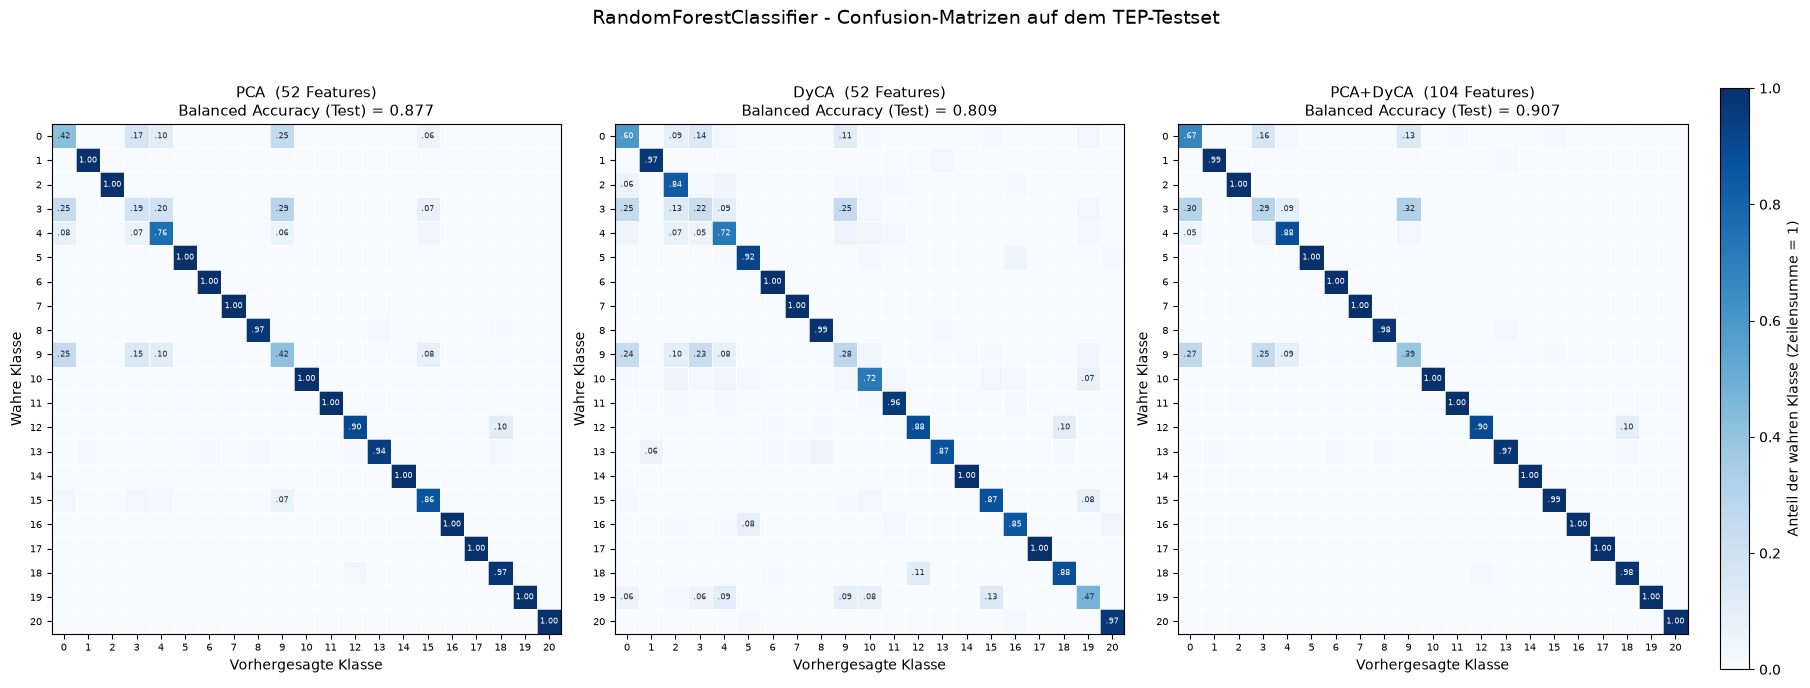

In [7]:
# ============================================================
# Plot: die Confusion-Matrizen nebeneinander
# ============================================================
# Zeilenweise normiert (Zeilensumme = 1): Zelle (i, j) ist der Anteil der
# wahren Klasse i, der als j vorhergesagt wurde - die Diagonale also der
# Recall. Gemeinsame Farbskala 0..1, damit die Panels vergleichbar sind.
_ = plot_confusions(cm_results, annot_min=0.05)

In [8]:
# ============================================================
# Groesste Verwechslungen und absolute Zaehlwerte
# ============================================================
report_confusions(cm_results, top_n=8)

cm_counts = counts(cm_results)
cm_counts[SETS[-1].name]


=== PCA: groesste Verwechslungen (Top 8) ===
  wahr  3 -> vorhergesagt  9:  147 Runs (29.4% der Klasse)
  wahr  0 -> vorhergesagt  9:  127 Runs (25.4% der Klasse)
  wahr  9 -> vorhergesagt  0:  126 Runs (25.2% der Klasse)
  wahr  3 -> vorhergesagt  0:  123 Runs (24.6% der Klasse)
  wahr  3 -> vorhergesagt  4:  100 Runs (20.0% der Klasse)
  wahr  0 -> vorhergesagt  3:   83 Runs (16.6% der Klasse)
  wahr  9 -> vorhergesagt  3:   74 Runs (14.8% der Klasse)
  wahr  9 -> vorhergesagt  4:   51 Runs (10.2% der Klasse)

=== DyCA: groesste Verwechslungen (Top 8) ===
  wahr  3 -> vorhergesagt  0:  126 Runs (25.4% der Klasse)
  wahr  3 -> vorhergesagt  9:  124 Runs (25.0% der Klasse)
  wahr  9 -> vorhergesagt  0:  117 Runs (23.6% der Klasse)
  wahr  9 -> vorhergesagt  3:  114 Runs (23.0% der Klasse)
  wahr  0 -> vorhergesagt  3:   68 Runs (13.7% der Klasse)
  wahr  3 -> vorhergesagt  2:   65 Runs (13.1% der Klasse)
  wahr 19 -> vorhergesagt 15:   63 Runs (12.7% der Klasse)
  wahr 18 -> vorherges

,pred_0,pred_1,pred_2,pred_3,pred_4,pred_5,pred_6,pred_7,pred_8,pred_9,...,pred_11,pred_12,pred_13,pred_14,pred_15,pred_16,pred_17,pred_18,pred_19,pred_20
true_0,333,0,0,81,11,0,0,0,0,66,...,2,0,0,0,4,0,0,0,0,0
true_1,0,495,0,0,0,1,0,0,0,0,...,0,0,3,0,0,0,0,0,0,0
true_2,0,0,498,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_3,148,0,0,144,46,0,0,0,0,157,...,0,0,0,0,0,0,0,0,0,0
true_4,27,0,0,19,438,0,0,0,0,15,...,0,0,0,0,0,0,0,0,0,0
true_5,0,0,0,0,0,495,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_6,0,0,0,0,0,0,493,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_7,0,0,0,0,0,0,0,499,0,0,...,0,0,0,0,0,0,0,0,0,0
true_8,0,0,0,0,0,1,0,0,489,0,...,0,0,8,0,0,0,0,0,0,0
true_9,135,0,0,123,43,0,0,0,0,192,...,0,0,0,0,3,0,0,0,0,0
